In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('data/data.csv')

Defining Functions

In [ ]:
# function to get the basic info about the dataset
def visual_data(df, hist_plot=True, corr_plot=True, multicollinear=True, corr_threshold=0.80):
    # basic info
    print("Data Information:")
    df.info()
    
    # first 10 rows
    print("\nFirst 10 rows:")
    print(df[:10])
    
    # duplicates
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    print(f"\nDuplicate Rows: {duplicate_count} ({duplicate_percentage:.2f}% of total rows)")

    # missing values
    missing_percentage = (df.isna().mean() * 100).round(2)
    total_missing = missing_percentage.sum()
    if total_missing > 0:
        print("\nMissing Values (%):")
        print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))
    else:
        print(f"\nMissing Values: 0.00%")
    
    # descriptive statistics for numeric columns
    print("\nDescriptive Statistics (Numerical):")
    print(df.describe().T.round(2))

    # descriptive statistics for categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'category'])
    print("\nDescriptive Statistics (Categorical):")
    print(categorical_cols.describe().T)

    # histogram
    if hist_plot:
        df.hist(bins=20, color='blue', edgecolor='black', 
        grid=False,figsize=(12, 8))
        plt.tight_layout()
        plt.show()
    
    # correlation heatmap
    if corr_plot:
        numeric_cols = df.select_dtypes(include=['number'])
        plt.figure(figsize=(8, 6))
        corr_matrix = numeric_cols.corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
        fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

    # multicollinearity
    if multicollinear and not numeric_cols.empty:
        print("\nChecking for Multicollinearity (Correlation Threshold > {:.2f}):".format(corr_threshold))
        high_corr_pairs = []
        corr_matrix = numeric_cols.corr().abs()  # Calculate correlation matrix for numeric columns only
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > corr_threshold:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        
        if high_corr_pairs:
            print("High correlation pairs found:")
            for pair in high_corr_pairs:
                print(f" - {pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")
        else:
            print("No highly correlated pairs found.")

    return df

In [ ]:
# function that defines who appears before and after Hume's Warbler (target specie) within 3 seconds window
def birds_around(df, name="hume's warbler", window=3):
  
    # Filter for events matching the target scientific name
    events = df[df['Common name'] == name]
    output_rows = []
    
    for _, event in events.iterrows():
        # Define the time windows:
        window_before_start = event['Start (s)'] - window
        window_before_end   = event['Start (s)']
        
        window_after_start = event['End (s)']
        window_after_end   = event['End (s)'] + window

        # Select birds in the "before" window
        birds_before = df[
            (df['Start (s)'] >= window_before_start) &
            (df['End (s)'] <= window_before_end)
        ]
        
        # Add window info for birds before the event
        for _, bird in birds_before.iterrows():
            row = bird.to_dict()
            row['Event_Start'] = event['Start (s)']
            row['Event_End'] = event['End (s)']
            row['Window'] = 'Before'
            output_rows.append(row)
        
        # Select birds in the "after" window
        birds_after = df[
            (df['Start (s)'] >= window_after_start) &
            (df['End (s)'] <= window_after_end)
        ]
        
        # Add window info for birds after the event
        for _, bird in birds_after.iterrows():
            row = bird.to_dict()
            row['Event_Start'] = event['Start (s)']
            row['Event_End'] = event['End (s)']
            row['Window'] = 'After'
            output_rows.append(row)
    
    result_df = pd.DataFrame(output_rows)
    result_df = result_df.drop_duplicates()
    return result_df

In [5]:
# merging cocontiguous intervals for rows with the same 'Scientific/Common name' 

def merge_contiguous_intervals(df):

    # Initialize the list to collect merged rows
    merged_rows = []
    
    # Start with the first row as the current interval
    current = df.iloc[0].copy()
    
    # Iterate over the DataFrame from the second row onward
    for idx in range(1, len(df)):
        row = df.iloc[idx]
        
        # If the same species and the intervals are contiguous, merge them
        if (row['Common name'] == current['Common name'] and 
            row['Start (s)'] == current['End (s)']):
            # Extend the current interval's end time
            current['End (s)'] = row['End (s)']
        else:
            # Append the current interval and start a new one
            merged_rows.append(current)
            current = row.copy()
    

    merged_rows.append(current)
    
    merged_df = pd.DataFrame(merged_rows)
    
    # Remove rows with a 3-second interval (i.e., where duration equals 3 seconds)
    merged_df = merged_df[(merged_df['End (s)'] - merged_df['Start (s)']) != 3]
    
    # Reset the index of the final DataFrame
    merged_df = merged_df.reset_index(drop=True)
    
    return merged_df




In [6]:
def explore_dataset(df):
    for column in df.columns:
        print(f"Column: {column}")
        print("Unique values:")
        print(df[column].unique())
        print("\nValue counts:")
        print(round(df[column].value_counts(normalize=True) * 100, 2))
        print("-" * 40)

In [7]:
def accuracy(data):
    accuracy = data['Confidence'].mean().round(3)
    accuracy_habitant = data[data['Habitant'] == 1]['Confidence'].mean().round(3)
    accuracy__non_habitant = data[data['Habitant'] == 0]['Confidence'].mean().round(3)

    print('Total accuracy:' , accuracy)
    print('Habitant accuracy:' , accuracy_habitant)
    print('Non Habitant accuracy:' , accuracy__non_habitant)
    print('_ ' *40)

In [8]:
data = data.drop(columns=['Unnamed: 0', 'Scientific name', 'Year'])
data_05 = data
data_06 = data[data['Confidence'] >= 0.6]
data_07 = data[data['Confidence'] >= 0.7]
data_08 = data[data['Confidence'] >= 0.8]
data_09 = data[data['Confidence'] >= 0.9]

In [9]:
accuracy(data_05)
accuracy(data_06)
accuracy(data_07)
accuracy(data_08)
accuracy(data_09)


Total accuracy: 0.756
Habitant accuracy: 0.77
Non Habitant accuracy: 0.697
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Total accuracy: 0.815
Habitant accuracy: 0.823
Non Habitant accuracy: 0.772
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Total accuracy: 0.866
Habitant accuracy: 0.871
Non Habitant accuracy: 0.837
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Total accuracy: 0.913
Habitant accuracy: 0.915
Non Habitant accuracy: 0.899
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Total accuracy: 0.957
Habitant accuracy: 0.957
Non Habitant accuracy: 0.953
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


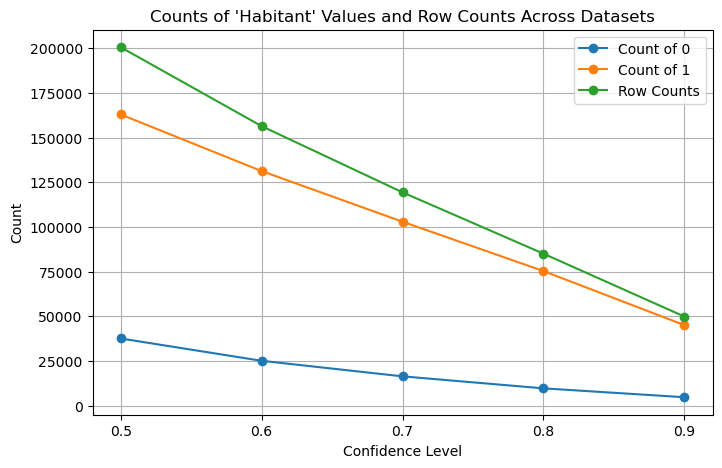

In [10]:

# Define dataset labels
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_0 = [d['Habitant'].value_counts().get(0, 0) for d in [data_05, data_06, data_07, data_08, data_09]]
counts_1 = [d['Habitant'].value_counts().get(1, 0) for d in [data_05, data_06, data_07, data_08, data_09]]

# Compute total row counts for each dataset
row_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Define x-axis positions
x = range(len(datasets))

plt.figure(figsize=(8, 5))
plt.plot(x, counts_0, marker='o', linestyle='-', label='Count of 0')
plt.plot(x, counts_1, marker='o', linestyle='-', label='Count of 1')
plt.plot(x, row_counts, marker='o', linestyle='-', label='Row Counts')

plt.xticks(x, datasets)
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.title("Counts of 'Habitant' Values and Row Counts Across Datasets")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
print(counts_0)
print(counts_1)
print(row_counts)


[37629, 25143, 16441, 9728, 4762]
[162979, 131306, 102968, 75362, 45133]
[200608, 156449, 119409, 85090, 49895]


In [12]:
# Absolute differences: difference between consecutive elements

abs_diff = np.diff(counts_0)

# Relative differences: (current - previous) / previous * 100
rel_diff = np.diff(counts_0) / counts_0[:-1] * 100
rel_diff = np.diff(counts_0) / counts_0[:-1] * 100
print("Absolute differences:", abs_diff)
print("Relative differences (%):", rel_diff)

Absolute differences: [-12486  -8702  -6713  -4966]
Relative differences (%): [-33.18185442 -34.61003062 -40.83084971 -51.04851974]


In [13]:
# Absolute differences: difference between consecutive elements

abs_diff = np.diff(counts_1)

# Relative differences: (current - previous) / previous * 100
rel_diff = np.diff(counts_1) / counts_1[:-1] * 100

print("Absolute differences:", abs_diff)
print("Relative differences (%):", rel_diff)

Absolute differences: [-31673 -28338 -27606 -30229]
Relative differences (%): [-19.43379208 -21.58164897 -26.81027115 -40.1117274 ]


In [14]:
# Absolute differences: difference between consecutive elements

abs_diff = np.diff(row_counts)

# Relative differences: (current - previous) / previous * 100
rel_diff = np.diff(row_counts) / row_counts[:-1] * 100

print("Absolute differences:", abs_diff)
print("Relative differences (%):", rel_diff)

Absolute differences: [-44159 -37040 -34319 -35195]
Relative differences (%): [-22.01258175 -23.67544695 -28.74071469 -41.3620872 ]


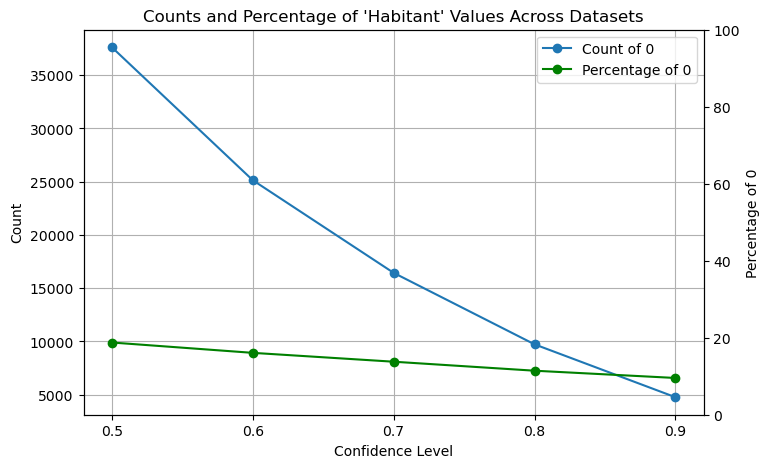

In [15]:
import matplotlib.pyplot as plt

# Define dataset labels
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_0 = [d['Habitant'].value_counts().get(0, 0) for d in [data_05, data_06, data_07, data_08, data_09]]

# Compute the percentage of 0 for each dataset
percentage_0 = [(c0 / total) * 100 for c0, total in zip(counts_0, row_counts)]

# Define x-axis positions
x = range(len(datasets))

# Create a figure and the primary y-axis for counts
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x, counts_0, marker='o', linestyle='-', label='Count of 0')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.grid(True)

# Create a secondary y-axis for the percentage
ax2 = ax1.twinx()
ax2.plot(x, percentage_0, marker='o', linestyle='-', color='green', label='Percentage of 0')
ax2.set_ylabel("Percentage of 0")
ax2.set_ylim(0, 100)  # Ensure the percentage axis goes from 0 to 100

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Counts and Percentage of 'Habitant' Values Across Datasets")
plt.show()


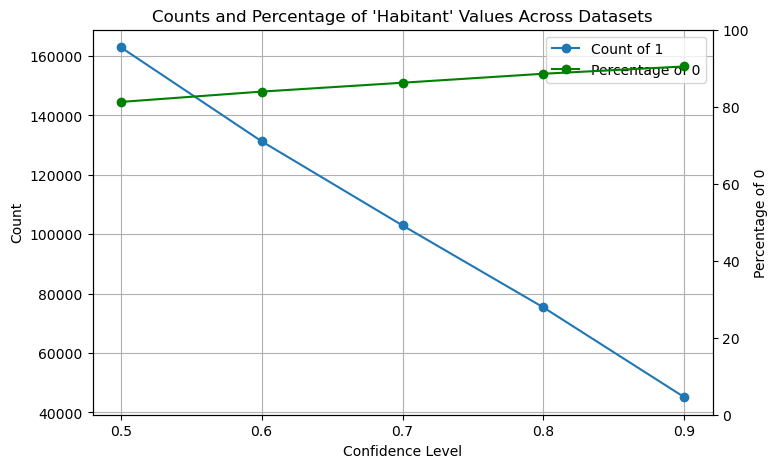

In [16]:
# Define dataset labels
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_1 = [d['Habitant'].value_counts().get(1, 0) for d in [data_05, data_06, data_07, data_08, data_09]]

# Compute the percentage of 0 for each dataset
percentage_1 = [(c1 / total) * 100 for c1, total in zip(counts_1, row_counts)]

# Define x-axis positions
x = range(len(datasets))

# Create a figure and the primary y-axis for counts
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x, counts_1, marker='o', linestyle='-', label='Count of 1')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.grid(True)

# Create a secondary y-axis for the percentage
ax2 = ax1.twinx()
ax2.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='Percentage of 0')
ax2.set_ylabel("Percentage of 0")
ax2.set_ylim(0, 100)  # Ensure the percentage axis goes from 0 to 100

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Counts and Percentage of 'Habitant' Values Across Datasets")
plt.show()


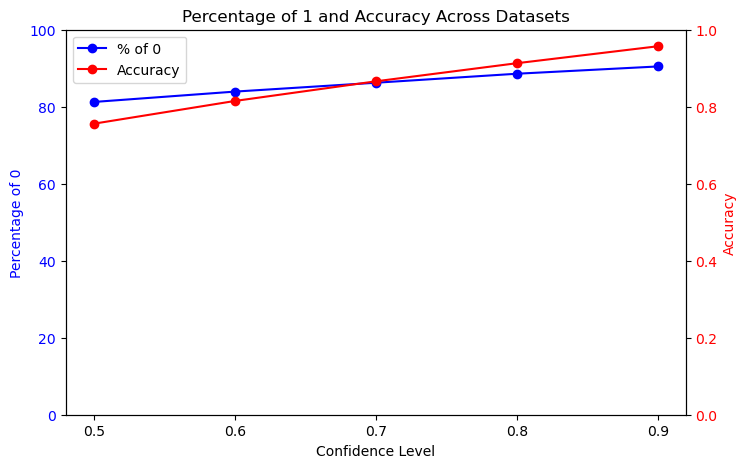

In [17]:
# Dataset labels for the x-axis
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Compute the percentage of 0 for each dataset
counts_1 = [d['Habitant'].value_counts().get(1, 0) for d in [data_05, data_06, data_07, data_08, data_09]]

# Compute the percentage of 0 for each dataset
percentage_1 = [(c1 / total) * 100 for c1, total in zip(counts_1, row_counts)]

row_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Compute accuracies (mean of 'Confidence') for each dataset
accuracies = [data_05['Confidence'].mean().round(3),
              data_06['Confidence'].mean().round(3),
              data_07['Confidence'].mean().round(3),
              data_08['Confidence'].mean().round(3),
              data_09['Confidence'].mean().round(3)]

# Define x-axis positions
x = range(len(datasets))

# Create a figure and primary axis for the percentage of 0
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel("Confidence Level")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylabel("Percentage of 0", color='blue')
ax1.plot(x, percentage_1, marker='o', linestyle='-', color='blue', label='% of 0')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 100)  # percentages between 0 and 100

# Create a twin axis for accuracies
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy", color='red')
ax2.plot(x, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)  # accuracies between 0 and 1

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Percentage of 1 and Accuracy Across Datasets")
plt.show()


In [18]:
accuracies

[0.756, 0.815, 0.866, 0.913, 0.957]

In [19]:
# Absolute differences: difference between consecutive elements

abs_diff = np.diff(accuracies)

# Relative differences: (current - previous) / previous * 100
rel_diff = np.diff(accuracies) / accuracies[:-1] * 100

print("Absolute differences:", abs_diff)
print("Relative differences (%):", rel_diff)

Absolute differences: [0.059 0.051 0.047 0.044]
Relative differences (%): [7.8042328  6.25766871 5.42725173 4.81927711]


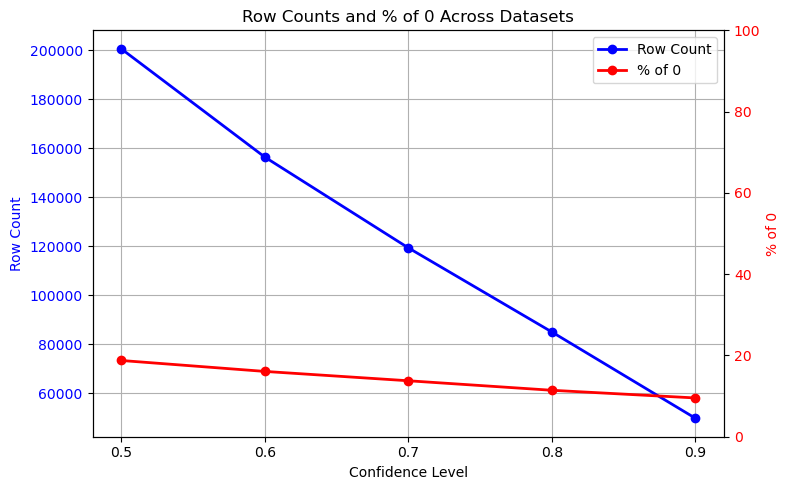

In [20]:
# Define dataset labels
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Compute row counts for each dataset
row_counts = [len(data_05), len(data_06), len(data_07), len(data_08), len(data_09)]

# Calculate the percentage of 0's for each dataset
error_05 = round(data_05['Habitant'].value_counts(normalize=True).get(0, 0) * 100, 2)
error_06 = round(data_06['Habitant'].value_counts(normalize=True).get(0, 0) * 100, 2)
error_07 = round(data_07['Habitant'].value_counts(normalize=True).get(0, 0) * 100, 2)
error_08 = round(data_08['Habitant'].value_counts(normalize=True).get(0, 0) * 100, 2)
error_09 = round(data_09['Habitant'].value_counts(normalize=True).get(0, 0) * 100, 2)
error_rates = [error_05, error_06, error_07, error_08, error_09]

# Create x-axis positions
x_positions = range(len(datasets))

# Create a figure and primary axis for row counts
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x_positions, row_counts, marker='o', linestyle='-', linewidth=2, color='blue', label='Row Count')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Row Count", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x_positions)
ax1.set_xticklabels(datasets)
ax1.grid(True)

# Create a twin axis to plot the error percentage (% of 0)
ax2 = ax1.twinx()
ax2.plot(x_positions, error_rates, marker='o', linestyle='-', linewidth=2, color='red', label='% of 0')
ax2.set_ylabel("% of 0", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)  # Set y-axis limit for percentages

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Row Counts and % of 0 Across Datasets")
plt.tight_layout()
plt.show()


In [21]:
error_rates

[18.76, 16.07, 13.77, 11.43, 9.54]

In [22]:
abs_diff = np.diff(error_rates)

# Relative differences: (current - previous) / previous * 100
rel_diff = np.diff(error_rates) / error_rates[:-1] * 100

print("Absolute differences:", abs_diff)
print("Relative differences (%):", rel_diff)

Absolute differences: [-2.69 -2.3  -2.34 -1.89]
Relative differences (%): [-14.33901919 -14.31238332 -16.99346405 -16.53543307]


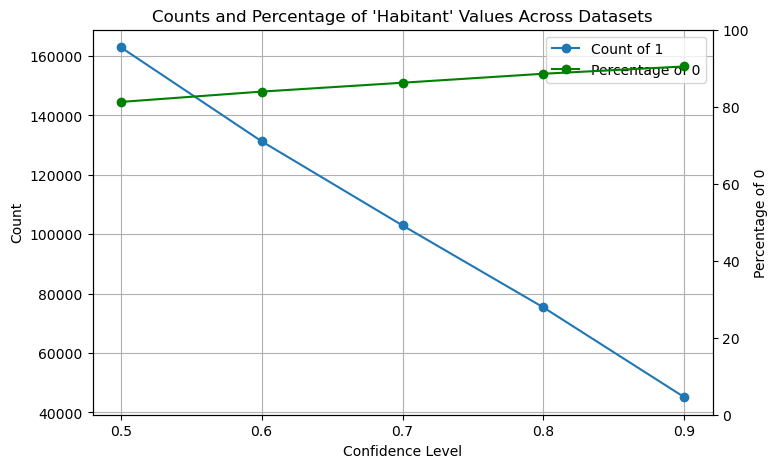

In [23]:
# Define dataset labels
datasets = ['0.5', '0.6', '0.7', '0.8', '0.9']

# Extract counts for values 0 and 1 for each dataset
counts_1 = [d['Habitant'].value_counts().get(1, 0) for d in [data_05, data_06, data_07, data_08, data_09]]

# Compute the percentage of 0 for each dataset
percentage_1 = [(c1 / total) * 100 for c1, total in zip(counts_1, row_counts)]

# Define x-axis positions
x = range(len(datasets))

# Create a figure and the primary y-axis for counts
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(x, counts_1, marker='o', linestyle='-', label='Count of 1')
ax1.set_xlabel("Confidence Level")
ax1.set_ylabel("Count")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.grid(True)

# Create a secondary y-axis for the percentage
ax2 = ax1.twinx()
ax2.plot(x, percentage_1, marker='o', linestyle='-', color='green', label='Percentage of 0')
ax2.set_ylabel("Percentage of 0")
ax2.set_ylim(0, 100)  # Ensure the percentage axis goes from 0 to 100

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("Counts and Percentage of 'Habitant' Values Across Datasets")
plt.show()


In [24]:
df = data_07


In [25]:
df = df[df['Habitant'] == 1]

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 102968 entries, 1 to 200603
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Start (s)    102968 non-null  float64
 1   End (s)      102968 non-null  float64
 2   Common name  102968 non-null  object 
 3   Confidence   102968 non-null  float64
 4   ID           102968 non-null  object 
 5   Month        102968 non-null  int64  
 6   Day          102968 non-null  int64  
 7   Time         102968 non-null  int64  
 8   Latitude     102968 non-null  float64
 9   Longitude    102968 non-null  float64
 10  Elevation    102968 non-null  int64  
 11  Habitant     102968 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 10.2+ MB

First 10 rows:
    Start (s)  End (s)     Common name  Confidence     ID  Month  Day  Time  \
1         6.0      9.0  hume's warbler      0.8799  psh10      6    4     6   
4        27.0     30.0  hume's warble

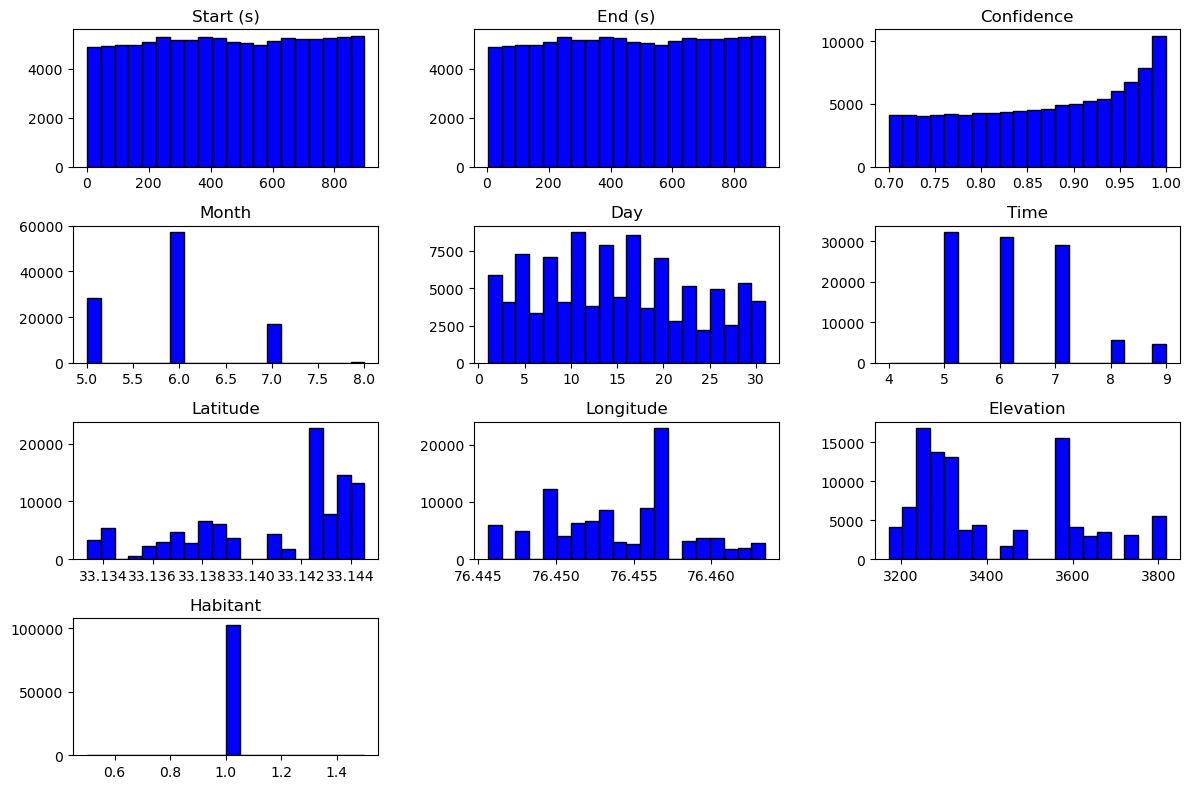

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


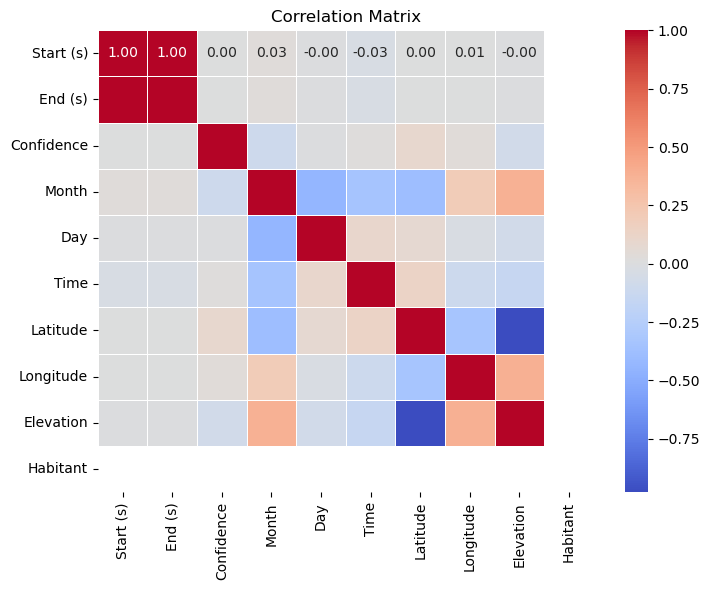


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.98


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant
1,6.0,9.0,hume's warbler,0.8799,psh10,6,4,6,33.135140,76.463139,3664,1
4,27.0,30.0,hume's warbler,0.8052,psh10,6,4,6,33.135140,76.463139,3664,1
5,39.0,42.0,hume's warbler,0.8985,psh10,6,4,6,33.135140,76.463139,3664,1
6,54.0,57.0,hume's warbler,0.7435,psh10,6,4,6,33.135140,76.463139,3664,1
7,60.0,63.0,hume's warbler,0.8016,psh10,6,4,6,33.135140,76.463139,3664,1
...,...,...,...,...,...,...,...,...,...,...,...,...
200599,54.0,57.0,variegated laughingthrush,0.8373,psm9,7,26,7,33.141258,76.461078,3438,1
200600,66.0,69.0,variegated laughingthrush,0.7415,psm9,7,26,7,33.141258,76.461078,3438,1
200601,72.0,75.0,variegated laughingthrush,0.8791,psm9,7,26,7,33.141258,76.461078,3438,1
200602,81.0,84.0,variegated laughingthrush,0.7492,psm9,7,26,7,33.141258,76.461078,3438,1


In [26]:
visual_data(df)

In [27]:
df_song = merge_contiguous_intervals(df)

In [28]:
df_song.to_csv('data/songs.csv')

In [29]:
# df_birds_3 = birds_around(df)
# df_birds_3.to_csv('data/birds_around_3.csv')

In [49]:
# Function to filter the dataset by groups
# based on the combination of 'ID', 'Month', 'Day', and 'Time' columns  
def filter_dataset_by_groups(df):
    # Create the temporary column 'Temp_ID' by concatenating the four columns as strings
    df['Temp_ID'] = (
        df['ID'].astype(str) + '_' +
        df['Month'].astype(str) + '_' +
        df['Day'].astype(str) + '_' +
        df['Time'].astype(str) + '_' +
        df['Start (s)'].astype(str) + '_' +
        df['End (s)'].astype(str)
    )
    
    # Filter the dataframe to include only groups with more than one row.
    # This will drop rows that are the only instance in their group.
    filtered_df = df.groupby('Temp_ID').filter(lambda group: len(group) > 1).reset_index(drop=True)
    
    return filtered_df

# Example usage:
# df = pd.read_csv("your_data.csv")
# new_df = filter_dataset_by_groups(df)
# print(new_df)


C:\Users\shang\AppData\Local\Temp\ipykernel_34392\1870538330.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Temp_ID'] = (


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start (s)    1383 non-null   float64
 1   End (s)      1383 non-null   float64
 2   Common name  1383 non-null   object 
 3   Confidence   1383 non-null   float64
 4   ID           1383 non-null   object 
 5   Month        1383 non-null   int64  
 6   Day          1383 non-null   int64  
 7   Time         1383 non-null   int64  
 8   Latitude     1383 non-null   float64
 9   Longitude    1383 non-null   float64
 10  Elevation    1383 non-null   int64  
 11  Habitant     1383 non-null   int64  
 12  Temp_ID      1383 non-null   object 
dtypes: float64(5), int64(5), object(3)
memory usage: 140.6+ KB

First 10 rows:
   Start (s)  End (s)            Common name  Confidence     ID  Month  Day  \
0      357.0    360.0         hume's warbler      0.9889  psh10      6    4   
1      

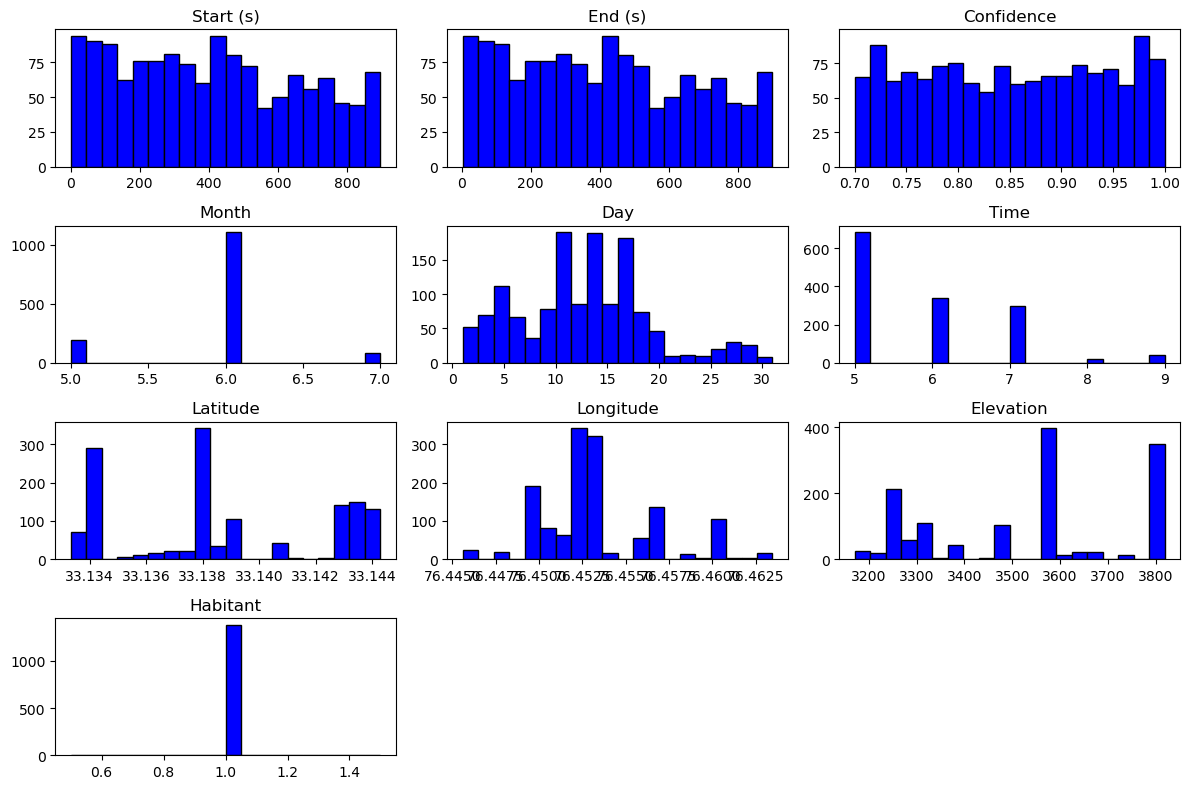

c:\Users\shang\Programs\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


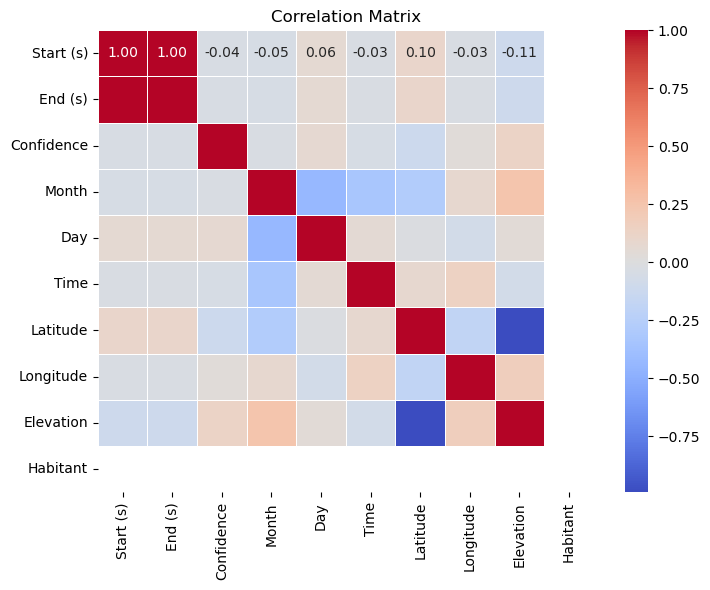


Checking for Multicollinearity (Correlation Threshold > 0.80):
High correlation pairs found:
 - End (s) and Start (s): Correlation = 1.00
 - Elevation and Latitude: Correlation = 0.99


,Start (s),End (s),Common name,Confidence,ID,Month,Day,Time,Latitude,Longitude,Elevation,Habitant,Temp_ID
0,357.0,360.0,hume's warbler,0.9889,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
1,357.0,360.0,himalayan bluetail,0.7929,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_357.0_360.0
2,414.0,417.0,himalayan bluetail,0.9378,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
3,414.0,417.0,buff-barred warbler,0.8451,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_414.0_417.0
4,486.0,489.0,hume's warbler,0.9941,psh10,6,4,6,33.135140,76.463139,3664,1,psh10_6_4_6_486.0_489.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,579.0,582.0,himalayan bluetail,0.7265,psm8,7,4,7,33.140866,76.449915,3370,1,psm8_7_4_7_579.0_582.0
1379,492.0,495.0,hume's warbler,0.8475,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1380,492.0,495.0,greenish warbler,0.7873,psm8,7,11,5,33.140866,76.449915,3370,1,psm8_7_11_5_492.0_495.0
1381,789.0,792.0,variegated laughingthrush,0.8647,psm9,6,2,7,33.141258,76.461078,3438,1,psm9_6_2_7_789.0_792.0


In [63]:
filter = filter_dataset_by_groups(df)
visual_data(filter) 

In [61]:
filter['Common name'].value_counts()

Common name
hume's warbler                      439
himalayan bluetail                  348
western crowned warbler             177
variegated laughingthrush           144
tytler's leaf warbler                84
greenish warbler                     73
olive-backed pipit                   23
rufous-breasted accentor             16
himalayan monal                      16
common rosefinch                     12
slaty-blue flycatcher                11
buff-barred warbler                   7
large-billed leaf warbler             5
rock bunting                          4
himalayan white-browed rosefinch      4
eurasian kestrel                      4
blue-fronted redstart                 4
tickell's leaf warbler                3
coal tit                              3
rufous-naped tit                      3
blue whistling-thrush                 1
pink-browed rosefinch                 1
eurasian wren                         1
Name: count, dtype: int64

In [64]:
pairs = filter.groupby('Temp_ID')['Common name'].apply(lambda x: tuple(sorted(x.unique())))
    
    # Count the frequency of each unique pair
pair_counts = pairs.value_counts()

In [65]:
pairs.value_counts()

Common name
(himalayan bluetail, hume's warbler)                      319
(tytler's leaf warbler, western crowned warbler)           82
(variegated laughingthrush, western crowned warbler)       73
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(olive-backed pipit, variegated laughingthrush)            21
(greenish warbler, himalayan bluetail)                     18
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(slaty-blue flycatcher, variegated laughingthrush)          4
(rock bunting, rufous-breasted accentor)                    4
(buff-barred warbler, himalayan bluetail)                   4
(eurasian kestrel, himalayan white-browed rosefinch)        4
(rufous-breasted accentor, variegated laughingthrush)       4
(hume's warbler, slaty-blue flycatcher)                   

In [66]:
pairs_with_hume = pair_counts[[ "hume's warbler" in combo for combo in pair_counts.index ]]
print(pairs_with_hume)

Common name
(himalayan bluetail, hume's warbler)                      319
(greenish warbler, hume's warbler)                         48
(hume's warbler, variegated laughingthrush)                33
(hume's warbler, western crowned warbler)                  11
(himalayan monal, hume's warbler)                          11
(common rosefinch, hume's warbler)                          5
(hume's warbler, slaty-blue flycatcher)                     3
(hume's warbler, tickell's leaf warbler)                    3
(hume's warbler, large-billed leaf warbler)                 2
(buff-barred warbler, hume's warbler)                       2
(hume's warbler, pink-browed rosefinch)                     1
(greenish warbler, himalayan bluetail, hume's warbler)      1
Name: count, dtype: int64
